# Heat Equation Solver

## 1. PDE model

考虑初边值偏微分方程组：

$$
\begin{cases}
u_t=u_{xx},\quad x\in (0,1),t>0,\\
u(t,0)=u(t,1)=0,\\
u(0,x)=\sin(\pi x). 
\end{cases}
$$

可知该方程的精确解为$u(t,x)=e^{-{\pi}^2 t}\sin(\pi x)$。利用有限差分构造近似解，研究稳定条件：

$$
\Delta t\leq C(\Delta x)^2,
$$

并改变时间步和空间网格，输出误差表。

## 2. Numerical Scheme

利用划分把网格写成：

$$
x_j=j\Delta x,\quad t^n=n\Delta t, \quad u_j^n\approx u(t^n,x_j),
$$

时间变量利用Forward Euler近似如下：

$$
u_t(t^n,x_j)\approx \frac{u_j^{n+1}-u_j^n}{\Delta t},
$$

空间变量利用中心有限差分得到：

$$
u_{xx}(t^n,x_j)\approx \frac{u_{j+1}^n-2u_j^n+u_{j-1}^n}{(\Delta x)^2},
$$

代入$u_t=u_{xx}$得到迭代求解公式：

$$
u_{j}^{n+1}=u_j^n+r(u_{j+1}^n-2u_j^n+u_{j-1}^n),
$$

其中

$$
r=\frac{\Delta t}{(\Delta x)^2}.
$$

## 3. Consistency Analysis

对时间方向，在$(t^n,x_j)$处Taylor展开：

$$
u(t^{n+1},x_j)=u(t^n,x_j)+\Delta t u_t+\frac{\Delta t^2}{2}u_{tt}+O(\Delta t^3). 
$$

所以

$$
\frac{u(t^{n+1},x_j)-u(t^n,x_j)}{\Delta t}=u_t+\frac{\Delta t}{2}u_{tt}+O(\Delta t^2). 
$$

因此时间离散误差是一阶的：

$$
O(\Delta t)
$$

空间方向则有

$$
u(t^n,x_j+\Delta x)=u+\Delta x u_x+\frac{\Delta x^2}{2}u_{xx}+\frac{\Delta x^3}{6}u_{xxx}+\frac{\Delta x^4}{24}u_{xxxx}+O(\Delta x^5),
$$

以及

$$
u(t^n,x_j-\Delta x)=u-\Delta x u_x+\frac{\Delta x^2}{2}u_{xx}-\frac{\Delta x^3}{6}u_{xxx}+\frac{\Delta x^4}{24}u_{xxxx}+O(\Delta x^5),
$$

两式相加后得到

$$
\frac{u(t^n,x_j+\Delta x)-2u(t^n,x_j)+u(t^n,x_j-\Delta x)}{\Delta x^2}=u_{xx}+\frac{\Delta x^2}{12}u_{xxxx}+O(\Delta x^4). 
$$

因此空间离散误差是

$$
O(\Delta x^2)
$$

所以，将真实解代入离散格式后的局部截断误差满足

$$
\tau_j^n=O(\Delta t+\Delta x^2). 
$$

当

$$
\Delta t\to 0,\qquad \Delta x\to 0
$$

得到

$$
\tau_j^n \to 0. 
$$

因此该数值格式与原heat equation是consistent。


## 4. Python Implementation

In [24]:
import numpy as np
import matplotlib.pyplot as plt 

#Generate iteration function 
def heat_eq_solver(N_x,dt,u_old):
    dx=1/N_x
    r=dt/(dx)**2
    u_new=np.zeros(N_x+1)
    u_new[1:-1]=r*u_old[2:]+(1-2*r)*u_old[1:-1]+r*u_old[:-2]
    return u_new


## 5. Stability Experiment

Note that $r=\frac{\Delta t}{\Delta x^2}$, the restriction 

$$
r\leq \frac{1}{2}
$$

makes sure that the forward euler method is stable. 

Take $N_x=20$ for example, we have $\Delta x=0.05$. Hence 
- $\Delta t=0.001$, $r=0.4<0.5$,
- $\Delta t=0.004$, $r=1.6>0.5$,

we shall compare the two cases in the following.

Take dt=0.004, $u_j^n$ at time 0.1 is:
 [  0.           1.86190011  -3.7649842    6.56778188  -9.21021013
  13.15461739 -16.44785415  21.32748309 -25.53232496  32.13091575
 -38.73137855  48.44705955 -58.0893939   69.42036634 -77.88498037
  83.51825283 -81.66506156  72.48689115 -54.14725585  29.1941134
   0.        ]
Take dt=0.001, $u_j^n$ at time 0.1 is:
 [0.         0.05813814 0.11484472 0.16872345 0.21844764 0.26279293
 0.30066739 0.33113841 0.35345571 0.36706976 0.37164533 0.36706976
 0.35345571 0.33113841 0.30066739 0.26279293 0.21844764 0.16872345
 0.11484472 0.05813814 0.        ]


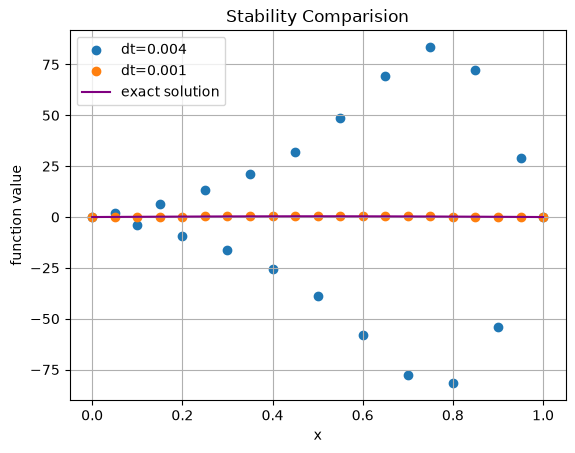

In [25]:
#Stability comparision
N_x=20
t_sample=[0.004,0.001]
X=np.linspace(0,1,N_x+1)
u_0=np.sin(np.pi*X)

#Calculate the iteration function u_j^n at time T=0.1
for dt in t_sample:
    temp=u_0
    for _ in range(int(0.1/dt)):
        temp=heat_eq_solver(N_x,dt,temp)
        
    print(f'Take dt={dt}, $u_j^n$ at time 0.1 is:\n',temp)
    plt.scatter(X,temp,label=f'dt={dt}')

#Plot
exact_u=np.exp(-(np.pi)**2*0.1)*np.sin(np.pi*X)
plt.plot(X,exact_u,label='exact solution',color='purple')
plt.xlabel(r'x')
plt.ylabel(r'function value')
plt.title(r'Stability Comparision')
plt.legend()
plt.grid()
plt.savefig('figures/stability_comparison.png',
            dpi=300,
            bbox_inches='tight')
plt.show()


### Numerical vs exact solution

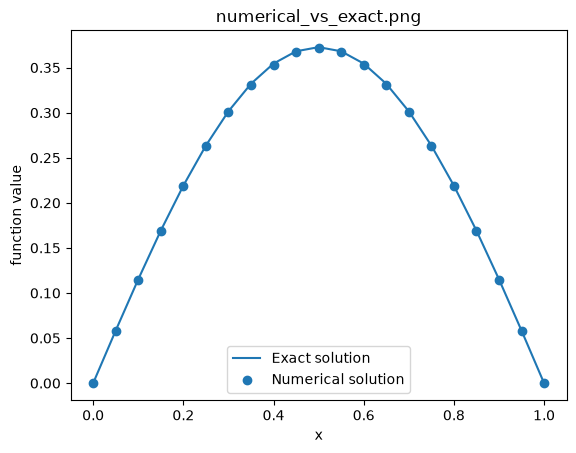

In [26]:
plt.plot(X, exact_u, label='Exact solution')
plt.scatter(X, temp, label='Numerical solution')
plt.xlabel(r'x')
plt.ylabel(r'function value')
plt.title(r'numerical_vs_exact.png')
plt.legend()
plt.savefig('figures/numerical_vs_exact.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

## 6. Convergence Experiment

Take

$$
\Delta t=0.4(\Delta x)^2,
$$

and set 

$$
E_h=\max_j |u_j^N-u(T,x_j)|,
$$

We define that 

$$
p=\frac{\log (E_h/E_{h/2})}{\log 2}
$$

be the convergence order.

error: [2.63435643e-03 6.55814473e-04 1.63781121e-04 4.09345134e-05]
the convergent order p is [2.00609091 2.00151867 2.00037942]


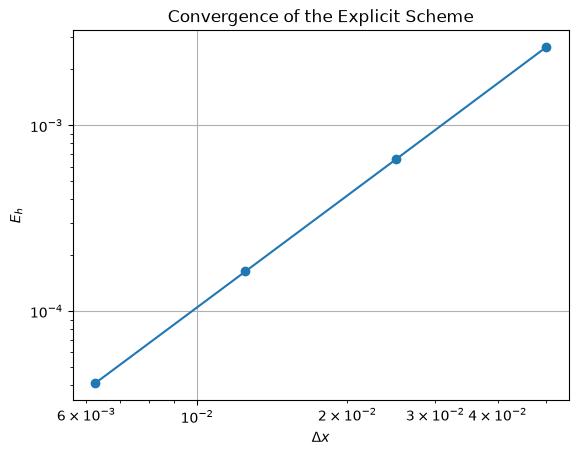

In [28]:
#Convergence 
Nx=[20,40,80,160]
T=0.1
error=[]
p=[]
for N_x in Nx:
    X=np.linspace(0,1,N_x+1)
    u_exact=np.exp(-(np.pi)**2*T)*np.sin(np.pi*X)
    dt=0.4*(1/N_x)**2
    temp=np.sin(np.pi*X)
    for _ in range(int(T/dt)):
        temp=heat_eq_solver(N_x,dt,temp)
    du=np.abs(u_exact-temp)
    error.append(max(du))
error=np.array(error)
print('error:',error)
p=np.log(error[:-1]/error[1:])/np.log(2)
print('the convergent order p is',p)
plt.loglog(1/np.array(Nx),error,'o-')
plt.xlabel(r'$\Delta x$')
plt.ylabel(r'$E_h$')
plt.title('Convergence of the Explicit Scheme')
plt.grid(True)
#plt.legend()

plt.savefig('figures/convergence.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

## 7. Conclusion

The observed convergence order approaches $2$, which agrees with the theoretical error $O(\Delta t+\Delta x^2)$. Since $\Delta t=0.4\Delta x^2$, the total error behaves as $O(\Delta x^2)$.